# Chapter 3: Kinematics in 2D

We use the **planar 2R robot** as a running example throughout this chapter. The key advantage of working in 2D is that all essential concepts — forward kinematics, inverse kinematics, velocity kinematics, and transformation matrices — can be understood using elementary trigonometry before generalizing to 3D in Chapter 4.

The chapter is organized as follows:
- **Section 3.1** introduces the 2R robot and its parameters.
- **Section 3.2** solves forward and inverse *position* kinematics using pure geometry.
- **Section 3.3** derives *velocity* kinematics by differentiating the position equations, leading to the Jacobian.

## 3.1 A 2D Planar Robot

A **planar 2R robot** has two rigid links connected by two revolute (rotary) joints, with all motion confined to a plane.

**Parameters:**

| Symbol | Meaning |
|--------|---------|
| $l_1$ | Length of link 1 |
| $l_2$ | Length of link 2 |
| $\theta_1$ | Angle of joint 1, measured from the positive $x$-axis |
| $\theta_2$ | Angle of joint 2, measured **relative to the direction of link 1** |

> **Why is $\theta_2$ relative to link 1, not the global $x$-axis?**  
> Because joint 2 is physically mounted on link 1. When joint 1 rotates, the whole second link rotates with it — so measuring $\theta_2$ from link 1's direction captures the actual rotation at that joint. The absolute angle of link 2 in the global frame is $\theta_1 + \theta_2$.

**Key positions:**
- Base: $\mathbf{p}_0 = (0,\ 0)$
- Elbow: $\mathbf{p}_1 = (l_1\cos\theta_1,\ l_1\sin\theta_1)$
- End-effector: $\mathbf{p}_2 = (x,\ y)$

In the widget below, the **dashed lines** show the reference direction each angle is measured from. The **arcs** show the actual angles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, FloatSlider
%matplotlib inline

In [ ]:
def _draw_angle_arc(ax, center, radius, ref_deg, angle_deg, color, label):
    """Draw a labeled arc showing angle_deg measured from the ref_deg direction."""
    if abs(angle_deg) < 1.0:
        return
    a_start = min(ref_deg, ref_deg + angle_deg)
    a_end   = max(ref_deg, ref_deg + angle_deg)
    arc = mpatches.Arc(center, 2*radius, 2*radius,
                       angle=0, theta1=a_start, theta2=a_end,
                       color=color, lw=1.8, zorder=4)
    ax.add_patch(arc)
    mid_rad = np.radians((a_start + a_end) / 2)
    ax.text(center[0] + radius * 1.8 * np.cos(mid_rad),
            center[1] + radius * 1.8 * np.sin(mid_rad),
            label, color=color, fontsize=12, fontweight='bold',
            ha='center', va='center')


def draw_2R_robot(theta1_deg, theta2_deg, l1=1.0, l2=0.8, ax=None, show=True):
    """Draw a planar 2R robot given joint angles in degrees."""
    theta1 = np.radians(theta1_deg)
    theta2 = np.radians(theta2_deg)

    p0 = np.array([0.0, 0.0])
    p1 = np.array([l1 * np.cos(theta1), l1 * np.sin(theta1)])
    p2 = np.array([p1[0] + l2 * np.cos(theta1 + theta2),
                   p1[1] + l2 * np.sin(theta1 + theta2)])

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Reference lines (dashed) showing what each angle is measured from
    r_ref = 0.42
    ax.plot([0, r_ref], [0, 0], color='gray', lw=1, ls='--', zorder=2, alpha=0.8)
    ax.plot([p1[0], p1[0] + r_ref * np.cos(theta1)],
            [p1[1], p1[1] + r_ref * np.sin(theta1)],
            color='gray', lw=1, ls='--', zorder=2, alpha=0.8)

    # Angle arcs
    _draw_angle_arc(ax, [0.0, 0.0],     0.28, 0,         theta1_deg, 'steelblue', 'θ₁')
    _draw_angle_arc(ax, [p1[0], p1[1]], 0.20, theta1_deg, theta2_deg, 'tomato',    'θ₂')

    # Links
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color='steelblue', lw=6,
            solid_capstyle='round', label=f'Link 1  (l₁ = {l1} m)')
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='tomato', lw=6,
            solid_capstyle='round', label=f'Link 2  (l₂ = {l2} m)')

    # Joints and end-effector
    for p in [p0, p1]:
        ax.add_patch(plt.Circle(p, 0.05, color='black', zorder=5))
    ax.plot(*p2, 'g*', markersize=15, zorder=5, label='End-effector')

    ax.annotate('O', p0, xytext=(p0[0] + 0.07, p0[1] - 0.17), fontsize=11)
    ax.annotate('p₁', p1, xytext=(p1[0] + 0.07, p1[1] + 0.07), fontsize=11)

    ax.set_title(
        f'θ₁ = {theta1_deg:.0f}°,  θ₂ = {theta2_deg:.0f}°  →  '
        f'EE = ({p2[0]:.3f}, {p2[1]:.3f}) m', fontsize=12)
    r = l1 + l2 + 0.3
    ax.set_xlim(-r, r);  ax.set_ylim(-r, r)
    ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5);  ax.axvline(0, color='gray', lw=0.5)
    ax.legend(loc='upper right');  ax.set_xlabel('x (m)');  ax.set_ylabel('y (m)')

    if show:
        plt.tight_layout();  plt.show()
    return p2


# interact requires the function to return None — wrap draw_2R_robot to drop its return value
def _robot_widget(theta1_deg, theta2_deg):
    draw_2R_robot(theta1_deg, theta2_deg)

interact(_robot_widget,
         theta1_deg=FloatSlider(value=45, min=-180, max=180, step=1, description='θ₁ (°)'),
         theta2_deg=FloatSlider(value=60, min=-180, max=180, step=1, description='θ₂ (°)'));

interactive(children=(FloatSlider(value=45.0, description='θ₁ (°)', max=180.0, min=-180.0, step=1.0), FloatSli…

> **Key Takeaways — Section 3.1**
> - The 2R robot has four parameters: $l_1$, $l_2$, $\theta_1$, $\theta_2$.
> - $\theta_2$ is measured *relative to link 1*, not the global $x$-axis. The absolute angle of link 2 is $\theta_1 + \theta_2$.
> - The reachable workspace is an annulus: inner radius $|l_1 - l_2|$, outer radius $l_1 + l_2$.

## 3.2 Position Kinematics

Position kinematics addresses two complementary problems:

- **Forward kinematics (FK):** Given $(\theta_1, \theta_2)$, find the end-effector position $(x, y)$.
- **Inverse kinematics (IK):** Given desired $(x, y)$, find $(\theta_1, \theta_2)$.

FK is always unique and straightforward. IK is more challenging — for the 2R robot there are generally **two solutions** for each reachable target, corresponding to the *elbow-down* and *elbow-up* configurations.

### 3.2.1 Forward Kinematics

The end-effector position is found by summing the vector contribution of each link.

- Link 1 has length $l_1$ and points at angle $\theta_1$ from the $x$-axis.
- Link 2 has length $l_2$ and points at angle $\theta_1 + \theta_2$ from the $x$-axis (because $\theta_2$ is measured from link 1, which is already rotated by $\theta_1$).

$$\boxed{x = l_1 \cos\theta_1 + l_2 \cos(\theta_1 + \theta_2)}$$
$$\boxed{y = l_1 \sin\theta_1 + l_2 \sin(\theta_1 + \theta_2)}$$

**Sanity check:** Set $\theta_1 = 90°$, $\theta_2 = 0°$. Both links point straight up, so we expect $x = 0$, $y = l_1 + l_2$. Plugging in: $x = l_1\cos 90° + l_2\cos 90° = 0$ ✓, $y = l_1\sin 90° + l_2\sin 90° = l_1 + l_2$ ✓.

In [3]:
def forward_kinematics(theta1, theta2, l1=1.0, l2=0.8):
    """
    Forward kinematics for the planar 2R robot.
    theta1, theta2 : joint angles in radians
    Returns (x, y) end-effector position.
    """
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
    return x, y


# Numerical example
theta1 = np.radians(45)
theta2 = np.radians(60)
x, y = forward_kinematics(theta1, theta2)
print(f'θ₁ = 45°, θ₂ = 60°  →  End-effector: ({x:.4f}, {y:.4f}) m')

# Sanity checks: manually verify a few obvious configurations
print('\nSanity checks:')
sanity = [
    (  0,   0, 'Both links along +x  →  expect (1.8, 0.0)'),
    ( 90,   0, 'Both links straight up  →  expect (0.0, 1.8)'),
    (  0, 180, 'Link 2 folds back  →  expect (0.2, 0.0)  [= l₁−l₂]'),
    ( 90, -90, 'Link 2 points in +x at elbow  →  expect (0.8, 1.0)'),
]
for t1d, t2d, desc in sanity:
    xv, yv = forward_kinematics(np.radians(t1d), np.radians(t2d))
    print(f'  θ₁={t1d:4d}°, θ₂={t2d:4d}°:  ({xv:.4f}, {yv:.4f})   {desc}')

θ₁ = 45°, θ₂ = 60°  →  End-effector: (0.5001, 1.4798) m

Sanity checks:
  θ₁=   0°, θ₂=   0°:  (1.8000, 0.0000)   Both links along +x  →  expect (1.8, 0.0)
  θ₁=  90°, θ₂=   0°:  (0.0000, 1.8000)   Both links straight up  →  expect (0.0, 1.8)
  θ₁=   0°, θ₂= 180°:  (0.2000, 0.0000)   Link 2 folds back  →  expect (0.2, 0.0)  [= l₁−l₂]
  θ₁=  90°, θ₂= -90°:  (0.8000, 1.0000)   Link 2 points in +x at elbow  →  expect (0.8, 1.0)


#### Workspace of the Planar 2R Robot

The **workspace** is the set of all end-effector positions \(x,y\) the robot can reach as its joints move through their allowed angles.

For the 2R planar robot in this notebook \(l_1=1.0\), \(l_2=0.8\):

- **Maximum reach** (arm fully stretched):  
    $$  
    r_{\max}=l_1+l_2=1.8    
    $$
- **Minimum reach** (arm folded back):  
    $$
    r_{\min}=|l_1-l_2|=0.2
    $$

So the reachable region is an **annulus** (ring) centered at the base:
$$
0.2 \le \sqrt{x^2+y^2} \le 1.8
$$

In the code below, `plot_workspace()` samples many \($\theta_1$,$\theta_2$\) pairs, computes FK points \(X,Y\), and visualizes this ring-shaped reachable set with inner and outer boundary circles.

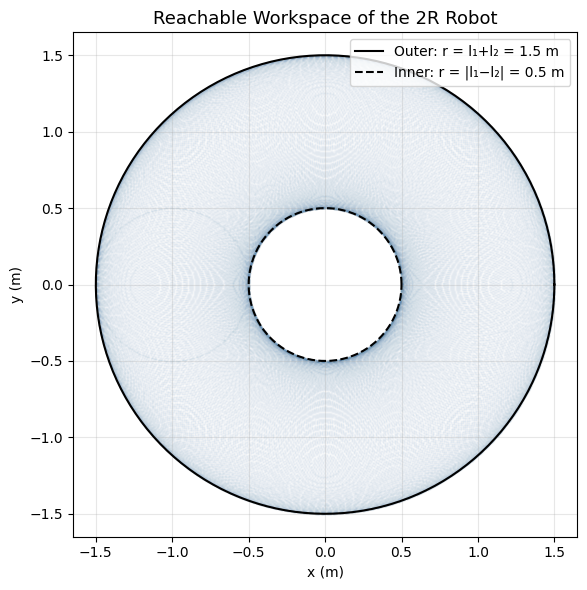

In [ ]:
def plot_workspace(l1=1.0, l2=0.8, n=400):
    """Visualise the reachable workspace of the 2R robot."""
    theta = np.linspace(-np.pi, np.pi, n)
    T1, T2 = np.meshgrid(theta, theta)
    X = l1 * np.cos(T1) + l2 * np.cos(T1 + T2)
    Y = l1 * np.sin(T1) + l2 * np.sin(T1 + T2)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(X.ravel(), Y.ravel(), s=0.4, alpha=0.03, color='steelblue')

    phi = np.linspace(0, 2 * np.pi, 300)
    for r, label, ls in [
        (l1 + l2,       f'Outer: r = l₁+l₂ = {l1+l2:.1f} m',       '-'),
        (abs(l1 - l2),  f'Inner: r = |l₁−l₂| = {abs(l1-l2):.1f} m', '--')
    ]:
        ax.plot(r * np.cos(phi), r * np.sin(phi), 'k', ls=ls, lw=1.5, label=label)

    ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
    ax.set_title('Reachable Workspace of the 2R Robot', fontsize=13)
    ax.set_xlabel('x (m)');  ax.set_ylabel('y (m)');  ax.legend()
    plt.tight_layout();  plt.show()


plot_workspace()

> **Key Takeaways — Section 3.2.1**
> - FK just sums the two link vectors: $x = l_1\cos\theta_1 + l_2\cos(\theta_1+\theta_2)$, same for $y$.
> - The absolute angle of link 2 in the global frame is $\theta_1 + \theta_2$, not $\theta_2$.
> - The workspace is an annulus with inner radius $|l_1 - l_2|$ and outer radius $l_1 + l_2$.

#### Math Tool: `atan2`

The inverse kinematics derivation uses `atan2(y, x)` rather than the ordinary `atan(y/x)`. Here is why:

- `atan(y/x)` only returns values in $(-90°, +90°)$ and fails when $x = 0$.
- `atan2(y, x)` returns the angle of the vector $(x, y)$ in the full range $(-180°, +180°]$, correctly handling all four quadrants.

| `atan2(y, x)` | result |
|--------------|--------|
| `atan2(0, 1)` | 0° |
| `atan2(1, 0)` | 90° |
| `atan2(0, -1)` | 180° |
| `atan2(-1, 0)` | -90° |
| `atan2(1, 1)` | 45° |
| `atan2(1, -1)` | 135° |
| `atan2(-1, 1)` | -45° |

In [6]:
# atan2 demonstration
print('atan2(y, x) returns the angle of the vector (x, y) in [-180°, +180°]:\n')
cases = [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (-1, 1), (1, -1)]
for y_val, x_val in cases:
    angle = np.degrees(np.arctan2(y_val, x_val))
    print(f'  atan2({y_val:2d}, {x_val:2d}) = {angle:7.1f}°')

print()
print('Compare with atan(y/x) — wrong quadrant when x < 0:')
for y_val, x_val in [(-1, -1), (1, -1)]:
    atan2_val = np.degrees(np.arctan2(y_val, x_val))
    atan_val  = np.degrees(np.arctan(y_val / x_val))
    print(f'  y={y_val:2d}, x={x_val:2d}:  atan2 = {atan2_val:.1f}°  (correct),  '
          f'atan = {atan_val:.1f}°  (wrong quadrant)')

atan2(y, x) returns the angle of the vector (x, y) in [-180°, +180°]:

  atan2( 0,  1) =     0.0°
  atan2( 1,  0) =    90.0°
  atan2( 0, -1) =   180.0°
  atan2(-1,  0) =   -90.0°
  atan2( 1,  1) =    45.0°
  atan2(-1,  1) =   -45.0°
  atan2( 1, -1) =   135.0°

Compare with atan(y/x) — wrong quadrant when x < 0:
  y=-1, x=-1:  atan2 = -135.0°  (correct),  atan = 45.0°  (wrong quadrant)
  y= 1, x=-1:  atan2 = 135.0°  (correct),  atan = -45.0°  (wrong quadrant)


### 3.2.2 Inverse Kinematics

**Physical picture first:** Think of the base, elbow, and end-effector as a triangle. The side lengths are $l_1$, $l_2$, and $r = \sqrt{x^2+y^2}$ (distance from base to target). The angle at the base of this triangle depends on $r$, $l_1$, $l_2$ — but *not* on the direction $\text{atan2}(y,x)$ to the target. This means we can find $\theta_2$ from the distance alone, then find $\theta_1$ using the direction. There are two triangles for the same side lengths (flip the elbow), giving the two solutions.

---

**Step 1 — Find $\theta_2$**

Square and add the FK equations:
$$x^2 + y^2 = [l_1\cos\theta_1 + l_2\cos(\theta_1+\theta_2)]^2 + [l_1\sin\theta_1 + l_2\sin(\theta_1+\theta_2)]^2$$

Expanding (cross terms use the cosine-subtraction identity $\cos A\cos B + \sin A\sin B = \cos(A-B)$):
$$= l_1^2(\cos^2\theta_1 + \sin^2\theta_1) + l_2^2(\cos^2(\theta_1+\theta_2) + \sin^2(\theta_1+\theta_2)) + 2l_1 l_2\cos\theta_2$$
$$= l_1^2 + l_2^2 + 2l_1 l_2\cos\theta_2$$

Solving:
$$\cos\theta_2 = \frac{x^2 + y^2 - l_1^2 - l_2^2}{2l_1 l_2}$$

Since $\sin^2\theta_2 + \cos^2\theta_2 = 1$, there are **two solutions** for $\theta_2$ (positive and negative square root):
$$\theta_2 = \text{atan2}\!\left(\pm\sqrt{1 - \cos^2\theta_2},\ \cos\theta_2\right)$$

> **Reachability:** If $|\cos\theta_2| > 1$ the target is outside the workspace — no solution exists.

---

**Step 2 — Find $\theta_1$**

With $\theta_2$ known, define:
$$\alpha = \text{atan2}(y,\ x) \quad\text{(direction from base to target)}$$
$$\beta  = \text{atan2}(l_2\sin\theta_2,\ l_1 + l_2\cos\theta_2) \quad\text{(correction angle due to link 2)}$$

Then:
$$\theta_1 = \alpha - \beta$$

The two values of $\theta_2$ (positive/negative) give two values of $\beta$, yielding the elbow-down and elbow-up solutions.

In [9]:
def inverse_kinematics(x, y, l1=1.0, l2=0.8):
    """
    Inverse kinematics for the 2R robot.
    Returns list of (theta1, theta2) solutions in radians:
      index 0 = elbow-down (+sin theta2)
      index 1 = elbow-up   (-sin theta2)
    Returns empty list if target is unreachable.
    """
    c2 = (x**2 + y**2 - l1**2 - l2**2) / (2 * l1 * l2)   # cos(theta2)

    if abs(c2) > 1.0:
        print(f'Target ({x:.3f}, {y:.3f}) is outside the workspace.')
        return []

    solutions = []
    for sign in [+1, -1]:                                   # elbow-down, elbow-up
        s2     = sign * np.sqrt(1 - c2**2)                  # sin(theta2)
        theta2 = np.arctan2(s2, c2)                         # theta2 in (-pi, pi]
        alpha  = np.arctan2(y, x)                           # direction to target
        beta   = np.arctan2(l2 * s2, l1 + l2 * c2)         # correction from link 2
        theta1 = alpha - beta
        solutions.append((theta1, theta2))

    return solutions


# Verify: apply FK to each IK solution and check it recovers the target
target = (1.0, 0.8)
sols = inverse_kinematics(*target)

print(f'Target: {target}')
for i, (t1, t2) in enumerate(sols):
    label = 'Elbow-down' if i == 0 else 'Elbow-up  '
    xc, yc = forward_kinematics(t1, t2)
    print(f'  {label}: θ₁={np.degrees(t1):7.2f}°,  θ₂={np.degrees(t2):7.2f}°  '
          f'→  FK check ({xc:.4f}, {yc:.4f})')

Target: (1.0, 0.8)
  Elbow-down: θ₁=   0.00°,  θ₂=  90.00°  →  FK check (1.0000, 0.8000)
  Elbow-up  : θ₁=  77.32°,  θ₂= -90.00°  →  FK check (1.0000, 0.8000)


In [10]:
def ik_interactive(target_x, target_y):
    l1, l2 = 1.0, 0.8
    sols = inverse_kinematics(target_x, target_y, l1, l2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    config_labels = ['Elbow-down', 'Elbow-up']
    colors = ['steelblue', 'darkorange']

    for ax, label, color in zip(axes, config_labels, colors):
        if not sols:
            ax.text(0.5, 0.5, 'Outside workspace',
                    ha='center', va='center', transform=ax.transAxes, fontsize=13)
        else:
            idx = config_labels.index(label)
            t1, t2 = sols[idx]
            p0 = np.array([0.0, 0.0])
            p1 = np.array([l1*np.cos(t1), l1*np.sin(t1)])
            p2 = np.array([p1[0] + l2*np.cos(t1+t2), p1[1] + l2*np.sin(t1+t2)])

            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, lw=6, solid_capstyle='round')
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=6, solid_capstyle='round', alpha=0.6)
            for p in [p0, p1]:
                ax.add_patch(plt.Circle(p, 0.04, color='black', zorder=5))
            ax.plot(*p2, 'g*', markersize=12, zorder=5, label='EE')
            ax.plot(target_x, target_y, 'rx', ms=14, mew=2.5, label='Target')
            ax.set_title(f'{label}\nθ₁={np.degrees(t1):.1f}°,  θ₂={np.degrees(t2):.1f}°', fontsize=12)
            ax.legend(loc='upper right')

        r = l1 + l2 + 0.2
        ax.set_xlim(-r, r);  ax.set_ylim(-r, r)
        ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
        ax.axhline(0, color='gray', lw=0.5);  ax.axvline(0, color='gray', lw=0.5)

    plt.suptitle(f'IK: Target = ({target_x:.2f}, {target_y:.2f}) m', fontsize=13)
    plt.tight_layout();  plt.show()


interact(ik_interactive,
         target_x=FloatSlider(value=1.0, min=-1.8, max=1.8, step=0.05, description='Target x (m)'),
         target_y=FloatSlider(value=0.8, min=-1.8, max=1.8, step=0.05, description='Target y (m)'));

interactive(children=(FloatSlider(value=1.0, description='Target x (m)', max=1.8, min=-1.8, step=0.05), FloatS…

> **Key Takeaways — Section 3.2.2**
> - Squaring and adding the FK equations eliminates $\theta_1$ and gives a direct formula for $\cos\theta_2$.
> - Two solutions exist because $\sin\theta_2 = \pm\sqrt{1-\cos^2\theta_2}$ (elbow-down and elbow-up).
> - Once $\theta_2$ is known, $\theta_1 = \text{atan2}(y,x) - \beta$ where $\beta$ accounts for link 2's offset.
> - Use `atan2`, not `atan`, to handle all quadrants correctly.

> **Practice Problems — Section 3.2**
>
> 1. Compute FK for $\theta_1 = 30°$, $\theta_2 = 90°$, $l_1 = 1$, $l_2 = 0.8$. Verify with the code.
> 2. Is the target $(1.5,\ 0.5)$ reachable? Find both IK solutions and confirm with FK.
> 3. What happens to the inner workspace radius when $l_1 = l_2$? What does this mean for IK at that boundary?
> 4. Try an unreachable target in `ik_interactive`. Where exactly is the boundary between reachable and unreachable?

## 3.3 Velocity Kinematics

The Jacobian relates the joint velocities to the end-effector's velocity. Specifically, it answers the question *"if the joints rotate at certain speeds, how fast does the end-effector move?"* It is the matrix that linearly maps joint velocities $(\dot{\theta}_1, \dot{\theta}_2)$ to end-effector velocity $(\dot{x}, \dot{y})$. Like all derivatives, it is only valid instantaneously at the current configuration — the robot's shape changes the relationship.

Differentiating the FK equations with respect to time (chain rule):

$$\dot{x} = \bigl[-l_1\sin\theta_1 - l_2\sin(\theta_1+\theta_2)\bigr]\dot{\theta}_1 + \bigl[-l_2\sin(\theta_1+\theta_2)\bigr]\dot{\theta}_2$$
$$\dot{y} = \bigl[l_1\cos\theta_1 + l_2\cos(\theta_1+\theta_2)\bigr]\dot{\theta}_1 + \bigl[l_2\cos(\theta_1+\theta_2)\bigr]\dot{\theta}_2$$

In matrix form:
$$\begin{bmatrix}\dot{x}\\\dot{y}\end{bmatrix} = \underbrace{\begin{bmatrix}-l_1\sin\theta_1-l_2\sin(\theta_1+\theta_2) & -l_2\sin(\theta_1+\theta_2)\\ l_1\cos\theta_1+l_2\cos(\theta_1+\theta_2) & l_2\cos(\theta_1+\theta_2)\end{bmatrix}}_{\mathbf{J}(\theta)}\begin{bmatrix}\dot{\theta}_1\\\dot{\theta}_2\end{bmatrix}$$

**Column interpretation:** Each column of $\mathbf{J}$ is the end-effector velocity produced when *only that joint moves at 1 rad/s*:
- **Column 1** ($\dot{\theta}_1=1, \dot{\theta}_2=0$): both links swing with joint 1, so the EE velocity has contributions from both.
- **Column 2** ($\dot{\theta}_1=0, \dot{\theta}_2=1$): only link 2 swings, so only link 2 contributes.

**Singularities:** $\det(\mathbf{J}) = l_1 l_2\sin\theta_2$.  
This is zero when $\theta_2 = 0°$ (arm fully extended) or $\theta_2 = \pm 180°$ (arm fully folded back). At these configurations the two links are collinear and the robot cannot move the end-effector perpendicular to that line — it has temporarily lost one degree of freedom.

In [8]:
def jacobian(theta1, theta2, l1=1.0, l2=0.8):
    """Analytic Jacobian of the 2R robot (2x2 matrix)."""
    s1  = np.sin(theta1)
    c1  = np.cos(theta1)
    s12 = np.sin(theta1 + theta2)
    c12 = np.cos(theta1 + theta2)
    return np.array([
        [-l1*s1 - l2*s12,  -l2*s12],
        [ l1*c1 + l2*c12,   l2*c12]
    ])


theta1, theta2 = np.radians(45), np.radians(60)
J = jacobian(theta1, theta2)

print('Jacobian at θ₁=45°, θ₂=60°:')
print(J.round(4))

# Column interpretation
print('\nColumn interpretation:')
v_col1 = J @ np.array([1.0, 0.0])
v_col2 = J @ np.array([0.0, 1.0])
print(f'  Only θ̇₁=1 rad/s  →  EE velocity = {v_col1.round(4)} m/s  (= col 1 of J)')
print(f'  Only θ̇₂=1 rad/s  →  EE velocity = {v_col2.round(4)} m/s  (= col 2 of J)')

# Full example
dtheta = np.array([0.5, -0.3])
v_ee   = J @ dtheta
print(f'\nWith θ̇₁=0.5, θ̇₂=-0.3 rad/s  →  EE velocity = {v_ee.round(4)} m/s')

print(f'\ndet(J) = {np.linalg.det(J):.4f}')
print(f'l₁ l₂ sin(θ₂) = {1.0 * 0.8 * np.sin(theta2):.4f}  (should match)')

Jacobian at θ₁=45°, θ₂=60°:
[[-1.4798 -0.7727]
 [ 0.5001 -0.2071]]

Column interpretation:
  Only θ̇₁=1 rad/s  →  EE velocity = [-1.4798  0.5001] m/s  (= col 1 of J)
  Only θ̇₂=1 rad/s  →  EE velocity = [-0.7727 -0.2071] m/s  (= col 2 of J)

With θ̇₁=0.5, θ̇₂=-0.3 rad/s  →  EE velocity = [-0.5081  0.3121] m/s

det(J) = 0.6928
l₁ l₂ sin(θ₂) = 0.6928  (should match)


In [9]:
def velocity_interactive(theta1_deg, theta2_deg, dtheta1, dtheta2):
    l1, l2 = 1.0, 0.8
    t1, t2 = np.radians(theta1_deg), np.radians(theta2_deg)

    p0 = np.array([0.0, 0.0])
    p1 = np.array([l1*np.cos(t1), l1*np.sin(t1)])
    p2 = np.array([p1[0]+l2*np.cos(t1+t2), p1[1]+l2*np.sin(t1+t2)])

    J    = jacobian(t1, t2, l1, l2)
    v_ee = J @ np.array([dtheta1, dtheta2])
    detJ = np.linalg.det(J)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([p0[0],p1[0]], [p0[1],p1[1]], color='steelblue', lw=6, solid_capstyle='round')
    ax.plot([p1[0],p2[0]], [p1[1],p2[1]], color='tomato',    lw=6, solid_capstyle='round')
    for p in [p0, p1]:
        ax.add_patch(plt.Circle(p, 0.05, color='black', zorder=5))
    ax.plot(*p2, 'go', ms=10, zorder=5)

    if np.linalg.norm(v_ee) > 1e-6:
        scale = 0.6
        ax.annotate('', xy=p2+scale*v_ee, xytext=p2,
                    arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))
        ax.text(p2[0]+scale*v_ee[0]+0.05, p2[1]+scale*v_ee[1]+0.05,
                f'v = ({v_ee[0]:.2f}, {v_ee[1]:.2f}) m/s', color='purple', fontsize=10)

    warn = '  ⚠ Near singularity! (θ₂ ≈ 0° or ±180°)' if abs(detJ) < 0.15 else ''
    ax.set_title(f'θ₁={theta1_deg}°,  θ₂={theta2_deg}°  |  det(J)={detJ:.3f}{warn}', fontsize=11)
    r = l1+l2+0.3
    ax.set_xlim(-r,r);  ax.set_ylim(-r,r)
    ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5);  ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel('x (m)');  ax.set_ylabel('y (m)')
    plt.tight_layout();  plt.show()


interact(velocity_interactive,
         theta1_deg=FloatSlider(value=45,   min=-180, max=180,  step=1,   description='θ₁ (°)'),
         theta2_deg=FloatSlider(value=60,   min=-170, max=170,  step=1,   description='θ₂ (°)'),
         dtheta1   =FloatSlider(value=0.5,  min=-2.0, max=2.0,  step=0.1, description='θ̇₁ (rad/s)'),
         dtheta2   =FloatSlider(value=-0.3, min=-2.0, max=2.0,  step=0.1, description='θ̇₂ (rad/s)'));

interactive(children=(FloatSlider(value=45.0, description='θ₁ (°)', max=180.0, min=-180.0, step=1.0), FloatSli…

> **Key Takeaways — Section 3.3**
> - The Jacobian $\mathbf{J}(\theta)$ linearly maps joint velocities to end-effector velocity: $\dot{\mathbf{p}} = \mathbf{J}\dot{\boldsymbol{\theta}}$.
> - Column $i$ of $\mathbf{J}$ is the EE velocity when *only* joint $i$ rotates at 1 rad/s.
> - $\det(\mathbf{J}) = l_1 l_2 \sin\theta_2$: zero when the arm is fully extended or fully folded.
> - At a singularity the robot cannot move in one Cartesian direction, no matter what the joints do.

> **Practice Problems — Section 3.3**
>
> 1. At $\theta_1 = 0°$, $\theta_2 = 90°$, compute $\mathbf{J}$ by hand and verify with the code.
> 2. Slide $\theta_2$ slowly toward $0°$ in `velocity_interactive`. What happens to the velocity arrow and why?
> 3. Find a configuration where joint 1 rotation produces no $x$-velocity at the end-effector. What does the robot look like?
> 4. If the desired EE velocity is $(\dot{x},\dot{y}) = (1, 0)$, what joint velocities are required at $\theta_1=0°$, $\theta_2=90°$? (Hint: compute $\mathbf{J}^{-1}$ at that configuration.)

## 3.4 Simulating the 2R Robot using MuJoCo

MuJoCo is a physics engine widely used for robotics simulation and control. It provides efficient computation of kinematics, dynamics, and collisions. In this section, we use MuJoCo as a **kinematics engine** — without advancing time, so the physics only computes geometry — to validate the forward kinematics formulas we derived in Sections 3.2 and 3.3. You can find an introductory tutorial here: [MuJoCo Tutorial](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/tutorial.ipynb).

We build the same 2R arm ($l_1 = 1.0$ m, $l_2 = 0.8$ m) defined in MJCF (MuJoCo XML Format). In practice, robot models come from CAD software (SolidWorks, Fusion 360) → STL mesh export → URDF description → MJCF conversion. Here we write the XML by hand so every element is explicit and readable.

Three objects appear throughout every MuJoCo program:

| Object | What it represents |
|--------|--------------------|
| **`MjModel`** | Static robot structure — bodies, joints, geometries, sensors. Loaded once from XML; never changes during a run. |
| **`MjData`** | Time-varying state — joint angles (`qpos`), velocities (`qvel`), body poses (`xpos`, `xmat`), forces. |
| **`mj_forward(model, data)`** | Given angles in `data.qpos`, propagates the kinematic chain and writes every body's world-frame position into `data.xpos`. |

### 3.4.1 Defining the Robot in MJCF

An MJCF file is a plain-text XML file that describes the robot completely. The elements we need for a 2R arm:

| Element | Role |
|---------|------|
| `<body>` | A rigid link. **Nest** bodies inside each other to form a kinematic chain. |
| `<joint>` | Adds one degree of freedom: how this body moves relative to its parent. For a revolute joint use `type="hinge"`. |
| `<geom>` | A geometric shape (capsule, sphere, box, …) used for rendering and collision. |
| `<camera>` | A virtual viewpoint. We add a top-down camera to view the planar robot from above. |

**Kinematic tree** — XML nesting mirrors the physical chain:

```
worldbody
└── link1  ← joint1: hinge around z, relative to world
    └── link2  ← joint2: hinge around z, relative to link1
        └── end_effector  ← rigidly fixed to link2 (no joint)
```

**Key rule:** the `pos="…"` attribute of a `<body>` sets its origin **in its parent's local frame**.  
Writing `pos="1.0 0 0"` for `link2` means *"my origin is 1 m along link1's local x-axis"* — exactly the elbow.

The code cell below writes out the full MJCF, loads it into MuJoCo, and prints the resulting model structure.

In [10]:
# Install MuJoCo if not already available:
# !pip install mujoco

import mujoco

# MJCF: complete description of the 2R planar robot.
# l1 = 1.0 m,  l2 = 0.8 m  (same as Sections 3.2-3.6)
# The robot moves in the x-y plane; joints rotate about the z-axis.
XML_2R = """
<mujoco model="2R_planar_robot">

  <!-- No gravity: kinematics only -->
  <option gravity="0 0 0"/>

  <!-- ====================================================================
       SCENE APPEARANCE
       visual : global rendering settings (lighting, haze)
       asset  : textures and materials — referenced by geoms via material=""
  ==================================================================== -->
  <visual>
    <!-- headlight = flashlight attached to the camera.
         ambient prevents fully-shadowed areas from being pitch black. -->
    <headlight diffuse="0.5 0.5 0.5" ambient="0.3 0.3 0.3" specular="0.0 0.0 0.0"/>
    <!-- haze blends the far background with this blue-grey colour -->
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>

  <asset>
    <!-- Two-tone blue checkerboard floor texture.
         builtin="checker" generates the pattern entirely inside MuJoCo —
         no external image file needed.
         rgb1 / rgb2 = the two alternating tile colours. -->
    <texture name="floor_tex" type="2d" builtin="checker"
             rgb1="0.15 0.25 0.38" rgb2="0.22 0.38 0.55"
             width="512" height="512"/>
    <!-- Material wraps the texture and adds surface properties.
         texrepeat="6 6" tiles the checker 6 times per unit length.
         reflectance adds a subtle mirror-like sheen. -->
    <material name="floor_mat" texture="floor_tex" texrepeat="6 6"
              reflectance="0.2" shininess="0.1"/>

    <!-- Gradient skybox: blue at the horizon, dark at the top.
         type="skybox" tells MuJoCo to use this as the scene background. -->
    <texture name="skybox" type="skybox" builtin="gradient"
             rgb1="0.3 0.5 0.7" rgb2="0.05 0.05 0.15"
             width="512" height="512"/>
  </asset>

  <worldbody>

    <!-- Overhead directional light.
         dir points slightly off-axis for a natural look.
         castshadow="true" lets the links cast shadows on the floor. -->
    <light name="sun" pos="1 1 5" dir="-0.2 -0.2 -1"
           diffuse="0.8 0.8 0.8" specular="0.2 0.2 0.2" castshadow="true"/>

    <!-- Infinite ground plane with checker material.
         size="10 10 0.1" sets the half-extents of the rendered area.
         pos z=-0.02 places the floor just below the robot (which lives at z=0). -->
    <geom name="floor" type="plane" size="10 10 0.1" pos="0 0 -0.1"
          material="floor_mat"/>

    <!-- Top-down camera looking straight down the z-axis.
         pos    = (0, 0, 5) -- 5 m above the origin
         xyaxes = camera x-axis then y-axis in world frame;
                  "1 0 0  0 1 0" makes the camera look along -z (downward) -->
    <camera name="top" pos="0 0 5" xyaxes="1 0 0 0 1 0"/>

    <!-- Small cylinder marks the base (joint 1 location) -->
    <geom name="base_marker" type="cylinder" pos="0 0 0"
          size="0.07 0.07" rgba="0.15 0.15 0.15 1"/>

    <!-- =====================================================================
         LINK 1
         pos="0 0 0"  : link1 origin at the world origin
         joint1       : hinge (revolute) around the z-axis
    ===================================================================== -->
    <body name="link1" pos="0 0 0">
      <joint name="joint1" type="hinge" axis="0 0 1" pos="0 0 0"/>

      <!-- Capsule for link 1 (inset slightly so joint markers stay visible) -->
      <geom name="geom_link1" type="capsule"
            fromto="0.06 0 0   0.94 0 0"
            size="0.04" rgba="0.25 0.47 0.80 1"/>

      <!-- Elbow marker at the tip of link 1 -->
      <geom name="elbow_marker" type="cylinder" pos="1.0 0 0"
            size="0.07 0.07" rgba="0.15 0.15 0.15 1"/>

      <!-- ===================================================================
           LINK 2
           pos="1.0 0 0"  : link2 origin at the elbow
           joint2          : hinge around z, relative to link1
      =================================================================== -->
      <body name="link2" pos="1.0 0 0">
        <joint name="joint2" type="hinge" axis="0 0 1" pos="0 0 0"/>

        <!-- Capsule for link 2 (length 0.8 m) -->
        <geom name="geom_link2" type="capsule"
              fromto="0.06 0 0   0.74 0 0"
              size="0.04" rgba="0.80 0.25 0.25 1"/>

        <!-- =================================================================
             END-EFFECTOR
             pos="0.8 0 0"  : tip of link 2, rigidly attached (no joint)
        ================================================================= -->
        <body name="end_effector" pos="0.8 0 0">
          <geom name="ee_marker" type="sphere" size="0.08" rgba="0.0 0.75 0.0 1"/>
        </body>

      </body>   <!-- end link2 -->
    </body>     <!-- end link1 -->

  </worldbody>
</mujoco>
"""

# Load the XML into MuJoCo
model = mujoco.MjModel.from_xml_string(XML_2R)
data  = mujoco.MjData(model)

print("=== Model summary ===")
print(f"  Bodies (including world):  {model.nbody}")
print(f"  Joints:                    {model.njnt}")
print(f"  qpos size:                 {model.nq}")
print()
print("=== Body index — data.xpos[id] gives world-frame (x, y, z) ===")
for i in range(model.nbody):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, i)
    print(f"  body[{i}]  '{name}'")
print()

# Look up body IDs by name (safer than hard-coding integers)
ee_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "end_effector")
l2_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "link2")
print(f"'end_effector' id = {ee_id}  ->  data.xpos[{ee_id}] = EE world position")
print(f"'link2'        id = {l2_id}  ->  data.xpos[{l2_id}] = elbow world position")


=== Model summary ===
  Bodies (including world):  4
  Joints:                    2
  qpos size:                 2

=== Body index — data.xpos[id] gives world-frame (x, y, z) ===
  body[0]  'world'
  body[1]  'link1'
  body[2]  'link2'
  body[3]  'end_effector'

'end_effector' id = 3  ->  data.xpos[3] = EE world position
'link2'        id = 2  ->  data.xpos[2] = elbow world position


### 3.4.2 Forward Kinematics with MuJoCo

The MuJoCo FK workflow is always the same three lines — and will look identical whether the robot has 2 joints or 20:

```python
data.qpos[0] = theta1           # 1. write joint angles in radians
data.qpos[1] = theta2
mujoco.mj_forward(model, data)  # 2. propagate the kinematic chain
ee_pos = data.xpos[ee_id]       # 3. read any body's world-frame position
```

`data.xpos` is a NumPy array with shape `(nbody, 3)`. After `mj_forward`, row `i` holds the `(x, y, z)` world-frame position of body `i`'s origin.

The cell below computes the end-effector position for several configurations and compares all three FK methods side by side.

In [ ]:
# ── Compare geometric FK solution with MuJoco solution at several joint configurations ──────────────
#
# For each (θ₁, θ₂):
#   • Geometric FK  — trigonometric formulas   (Section 3.2.1)
#   • MuJoCo FK     — set qpos → mj_forward → read xpos

print("End-effector (x, y) in metres — three methods compared:")
print(f"  {'Config':22}  {'Geometric':>16}  {'MuJoCo':>16}  {'Match':>5}")
print("─" * 84)

configs = [(45, 60), (0, 0), (90, 0), (0, 180), (30, -60), (90, -90)]

for t1d, t2d in configs:
    t1 = np.radians(t1d)
    t2 = np.radians(t2d)

    # ── Method 1: Geometric ──────────────────────────────────────────────────
    x_geo, y_geo = forward_kinematics(t1, t2)

    # ── Method 2: MuJoCo ─────────────────────────────────────────────────────
    data.qpos[0] = t1                    # joint 1 angle (radians)
    data.qpos[1] = t2                    # joint 2 angle (radians)
    mujoco.mj_forward(model, data)       # propagate kinematic chain
    ee = data.xpos[ee_id]                # end-effector (x, y, z) in world frame
    # For our planar robot ee[2] ≈ 0 (no z motion); we use only ee[:2]

    # ── Check they all agree to 4 decimal places ─────────────────────────────
    match = (np.allclose([x_geo, y_geo], ee[:2],   atol=1e-4))

    print(f"  θ₁={t1d:4d}°, θ₂={t2d:4d}°"
          f"   ({x_geo:6.3f},{y_geo:6.3f})"
          f"   ({ee[0]:6.3f},{ee[1]:6.3f})"
          f"   {'✓' if match else '✗':>5}")

print()
print("Both methods return the same end-effector position ✓")
print()
print("The advantage of MuJoCo: no re-derivation needed for any new robot —")
print("define the MJCF, load it, and call mj_forward().")
print()
# Bonus: MuJoCo gives us ALL body positions, not just the end-effector.
# For example, here is the elbow position for the first configuration:
data.qpos[0] = np.radians(45)
data.qpos[1] = np.radians(60)
mujoco.mj_forward(model, data)
elbow = data.xpos[l2_id]   # link2's origin = elbow location
print(f"Bonus — elbow (link2 origin) at θ₁=45°, θ₂=60°: "
      f"({elbow[0]:.4f}, {elbow[1]:.4f})  m")
print(f"  Compare with geometric:  l₁·cos(θ₁) = {np.cos(np.radians(45)):.4f},  "
      f"l₁·sin(θ₁) = {np.sin(np.radians(45)):.4f}  ✓")

End-effector (x, y) in metres — three methods compared:
  Config                         Geometric            MuJoCo  Match
────────────────────────────────────────────────────────────────────────────────────
  θ₁=  45°, θ₂=  60°   ( 0.500, 1.480)   ( 0.500, 1.480)       ✓
  θ₁=   0°, θ₂=   0°   ( 1.800, 0.000)   ( 1.800, 0.000)       ✓
  θ₁=  90°, θ₂=   0°   ( 0.000, 1.800)   ( 0.000, 1.800)       ✓
  θ₁=   0°, θ₂= 180°   ( 0.200, 0.000)   ( 0.200, 0.000)       ✓
  θ₁=  30°, θ₂= -60°   ( 1.559, 0.100)   ( 1.559, 0.100)       ✓
  θ₁=  90°, θ₂= -90°   ( 0.800, 1.000)   ( 0.800, 1.000)       ✓

All three methods return the same end-effector position ✓

The advantage of MuJoCo: no re-derivation needed for any new robot —
define the MJCF, load it, and call mj_forward().

Bonus — elbow (link2 origin) at θ₁=45°, θ₂=60°: (0.7071, 0.7071)  m
  Compare with geometric:  l₁·cos(θ₁) = 0.7071,  l₁·sin(θ₁) = 0.7071  ✓


In [16]:
import mujoco.viewer   # requires mujoco >= 2.2.0

# ── Open the interactive viewer window ───────────────────────────────────────
#
# mujoco.viewer.launch_passive() opens a 3D viewer window WITHOUT blocking
# the notebook — you can keep running cells while the window is open.
#
# Inside the viewer window you can:
#   Left-click + drag    — rotate the scene
#   Right-click + drag   — pan
#   Scroll wheel         — zoom in / out
#   F1                   — show all keyboard shortcuts
#   Ctrl+M               — toggle the "Control" panel (built-in joint sliders)
#
# The notebook sliders below also control the joints in real time.
# Each time a slider moves, update_robot() writes the new angles to data.qpos,
# runs mj_forward(), then calls viewer.sync() to redraw the window.

viewer = mujoco.viewer.launch_passive(model, data)
print("MuJoCo viewer opened — look for a new window on your desktop.")
print("Use the sliders below, or press Ctrl+M in the viewer for its own controls.")


def update_robot(theta1_deg, theta2_deg):
    """Set joint angles, run FK, and push the updated pose to the viewer."""

    # 1. Write joint angles in radians (MuJoCo always uses radians internally)
    data.qpos[0] = np.radians(theta1_deg)   # joint 1
    data.qpos[1] = np.radians(theta2_deg)   # joint 2

    # 2. Propagate the kinematic chain (fills data.xpos with body positions)
    mujoco.mj_forward(model, data)

    # 3. Push the updated state to the viewer so it redraws the window.
    #    viewer.is_running() returns False if the user has closed the window.
    if viewer.is_running():
        viewer.sync()

    # 4. Print the computed end-effector position below the sliders
    ee_pos = data.xpos[ee_id]   # shape (3,) — (x, y, z) in world frame
    print(f"theta1={theta1_deg:+6.1f} deg  theta2={theta2_deg:+6.1f} deg"
          f"   ->   EE = ({ee_pos[0]:.4f}, {ee_pos[1]:.4f}) m")


interact(update_robot,
         theta1_deg=FloatSlider(value=45, min=-180, max=180, step=1, description='theta1 (deg)'),
         theta2_deg=FloatSlider(value=60, min=-180, max=180, step=1, description='theta2 (deg)'));

MuJoCo viewer opened — look for a new window on your desktop.
Use the sliders below, or press Ctrl+M in the viewer for its own controls.


interactive(children=(FloatSlider(value=45.0, description='theta1 (deg)', max=180.0, min=-180.0, step=1.0), Fl…

> **Key Takeaways — Section 3.4**
> - An MJCF file describes the robot as a tree of nested `<body>` elements. Each `<joint>` inside a body adds one degree of freedom relative to its parent.
> - `MjModel` holds the static robot structure (loaded once). `MjData` holds the current state — joint angles in `qpos`, body positions in `xpos`, etc.
> - **Three-line FK recipe**: write angles into `data.qpos` → call `mj_forward(model, data)` → read `data.xpos[body_id]`.
> - MuJoCo's FK gives the same end-effector positions as our geometric and HTM formulas — it is a more general engine that handles any kinematic tree in 2D or 3D without re-deriving formulas.
> - In later chapters we will use this same workflow to simulate the SO-ARM 101 (a real 6-joint robot), loading a CAD-derived MJCF file and calling `mj_forward` just as we do here.